# chrisMain — VarMeanNoise Analysis

Goal: pull stimulus + response data for the `varMeanNoise` protocol, then transfer cell types and STAs from the nearest noise (`SpatialNoise`) chunk via EI matching.

Steps:
1. Find every experiment that ran `varMeanNoise`
2. Pick a date
3. Build the pipeline (StimBlock + ResponseBlock for the protocol, AnalysisChunk for the noise chunk; `create_mea_pipeline` runs the EI-based cluster match automatically)
4. Sanity-check the matching by comparing RFs
5. Pull spike trains as an xarray for downstream analysis

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

/Users/chrischen/opt/anaconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/settings.py:979: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


[2026-05-12 16:55:08] DataJoint 2.1.1 connected to root@127.0.0.1:3306


## 1. Find all experiments that ran `varMeanNoise`

`get_datasets_from_protocol_names` does a lowercase substring match against the protocol registry, so `'varmeannoise'` will catch the full Java class name (e.g. `manookinlab.protocols.VarMeanNoise`). After the DB query we filter to only experiments whose sort output is actually present on disk (`ra.ANALYSIS_DIR`).

In [2]:
exp_search = ra.get_datasets_from_protocol_names('AlternatingBackground')

# Filter to experiments that exist on the MEA SSD
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop=True)

print(f'{len(exp_search)} usable datafile(s) found across '
      f'{exp_search.exp_name.nunique()} experiment(s).')
display(exp_search)


Found 1 protocols matching "alternatingbackground":
['edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']



Found 23 experiments, 32 epoch blocks.

27 usable datafile(s) found across 18 experiment(s).


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20220823C,data035,NaN,chunk5,edu.washington.riekelab.turner.protocols.EyeMo...,1,20220823C/data035,Eye movement trajectory alt background rod,22,41,315,866,45
1,20221006C,data029,1.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221006C/data029,Eye movement trajectory alternating background,25,41,386,972,54
2,20221101C,data018,0.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data018,Eye movement alt background,27,41,440,1047,56
3,20221101C,data025,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data025,Eye movement alt background,27,41,442,1054,57
4,20221101C,data032,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data032,Eye movement alt background,27,41,444,1061,57
5,20221123C,data027,2.0,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221123C/data027,CC eye movement alt background ndf2.0,30,41,530,1179,69
6,20230214C,data018,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230214C/data018,eye movement alt background ndf 3.0,39,41,781,1484,97
7,20230313C,data017,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data017,eye movement alt background ndf 3.0,42,41,878,1609,108
8,20230313C,data019,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data019,Var Mean Drift Grating ndf 3.0,42,41,879,1611,108
9,20230502C,data018,2.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230502C/data018,ndf 2.0 eye movement alt background,52,41,1077,1855,156


## 2. Pick a date

Set `exp_name` to one of the dates listed above. If that experiment ran `varMeanNoise` more than once (multiple datafiles), pick the specific one you want via `datafile_name` — by default we take the first.

In [3]:
exp_name = exp_search['exp_name'].iloc[0]   # <-- EDIT ME to pick a different date

datafiles_for_exp = exp_search.query('exp_name == @exp_name')['datafile_name'].values
print(f'{exp_name} has varMeanNoise in: {list(datafiles_for_exp)}')

datafile_name = datafiles_for_exp[0]        # <-- EDIT ME if more than one datafile
print(f'Using {exp_name} / {datafile_name}')

# Full summary of the chosen day — useful to see which datafiles are SpatialNoise (candidate chunks)
display(ra.get_exp_summary(exp_name))

20220823C has varMeanNoise in: ['data035']
Using 20220823C / data035


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20220823C,Mount1,data000,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.52,0.52,2022-08-23 10:00:48,2022-08-23 10:01:19,20220823C/data000,22,25,294,831,40,3
1,20220823C,Mount1,data001,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.52,1.25,2022-08-23 10:01:32,2022-08-23 10:02:03,20220823C/data001,22,25,294,832,40,3
2,20220823C,Mount1,data002,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.53,2.00,2022-08-23 10:02:16,2022-08-23 10:02:48,20220823C/data002,22,25,294,833,40,3
3,20220823C,Mount1,data003,noise cone,NaN,chunk1,manookinlab.protocols.FastNoise,30.75,33.63,2022-08-23 10:03:41,2022-08-23 10:34:26,20220823C/data003,22,25,295,834,40,1
4,20220823C,Mount1,data004,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.83,37.50,2022-08-23 10:37:28,2022-08-23 10:38:18,20220823C/data004,22,25,296,835,40,30
5,20220823C,Mount1,data005,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.80,38.47,2022-08-23 10:38:28,2022-08-23 10:39:16,20220823C/data005,22,25,296,836,40,30
6,20220823C,Mount1,data006,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.82,39.55,2022-08-23 10:39:32,2022-08-23 10:40:21,20220823C/data006,22,25,296,837,40,30
7,20220823C,Mount1,data007,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.80,40.48,2022-08-23 10:40:29,2022-08-23 10:41:17,20220823C/data007,22,25,296,838,40,30
8,20220823C,Mount1,data008,natural flash plus noise cone,NaN,chunk2,manookinlab.protocols.NaturalImageFlashPlusNoise,21.37,62.62,2022-08-23 10:42:03,2022-08-23 11:03:25,20220823C/data008,22,25,297,839,41,32
9,20220823C,Mount1,data009,CRF,NaN,chunk2,manookinlab.protocols.ContrastResponseGrating,0.55,64.93,2022-08-23 11:05:11,2022-08-23 11:05:44,20220823C/data009,22,25,298,840,41,3


## 3. Build the pipeline

`create_mea_pipeline` does everything in one shot:
- **StimBlock** — loads stimulus params and frame timing for the `varMeanNoise` datafile.
- **ResponseBlock** — loads spike times from the kilosort output for that datafile.
- **Nearest noise chunk** — auto-resolved from the experiment summary (whatever `SpatialNoise` chunk is closest in time). You can override this with `analysis_chunk_name='chunk2'` etc.
- **AnalysisChunk** — loads STAs, RF params, EIs, ISIs, timecourses, and the classification (cell type) file from the noise chunk.
- **EI-based cluster match** — `cluster_match()` is called internally to align the noise-chunk cell IDs to the protocol cell IDs by EI footprint correlation. After this, the protocol cells carry `noise_id` and `cell_type` columns.

In [4]:
# Older experiments are often sorted with kilosort2 (not 2.5). Auto-detect:
exp_sort_dir = os.path.join(ra.DATA_DIR, exp_name, datafile_name)
available_ss = [d for d in os.listdir(exp_sort_dir) if d.startswith('kilosort')]
ss_version = 'kilosort2.5' if 'kilosort2.5' in available_ss else available_ss[0]

# Auto-discover a typing file in the nearest noise chunk.
# Override `typing_file_name` below if you have a preferred classification file.
# We skip macOS dotfile siblings (e.g. `._kilosort2.classification.txt`) which
# are AppleDouble metadata, not text.
from retinanalysis.classes.stim import MEAStimBlock
_tmp_stim = MEAStimBlock(exp_name, datafile_name, verbose=False)
noise_chunk_name = _tmp_stim.nearest_noise_chunk
chunk_dir = os.path.join(ra.ANALYSIS_DIR, exp_name, noise_chunk_name, ss_version)
typing_candidates = [
    f for f in os.listdir(chunk_dir)
    if f.endswith('.classification.txt') and not f.startswith('.')
]
typing_file_name = typing_candidates[0]   # <-- EDIT ME to pick a specific classification file

print(f'ss_version: {ss_version}')
print(f'noise chunk: {noise_chunk_name}')
print(f'typing file: {typing_file_name}')
print(f'(other classification files in chunk: {typing_candidates})')

pipeline = ra.create_mea_pipeline(
    exp_name,
    datafile_name,
    ss_version=ss_version,
    typing_file=typing_file_name,
    # analysis_chunk_name=None,   # uncomment + set to override the auto-picked noise chunk
)

stim_block      = pipeline.stim
response_block  = pipeline.resp
analysis_chunk  = pipeline.analysis_chunk

print(f'\nNoise chunk used: {analysis_chunk.chunk_name}')
print(f'Cells in noise chunk: {len(analysis_chunk.cell_ids)}')
print(f'Cells in protocol datafile: {len(response_block.cell_ids)}')
print(f'Cells matched by EI: {len(pipeline.match_dict)}')

ss_version: kilosort2
noise chunk: chunk5
typing file: kilosort2.classification.txt
(other classification files in chunk: ['kilosort2.classification.txt'])


Initializing StimBlock for 20220823C block 866


For Rig C 20220823C:
{'disp_type': 'OLED', 'mu_per_pixel': 3.8, 'n_ht': 600, 'n_wt': 800, 'mean_frame_rate': 60.31807657, 'stage_frame_rate': np.float64(60.0), 'mea_rotation_deg': 90.0}


Nearest noise chunk for data035 is chunk5 with distance 29 minutes.



Initializing ResponseBlock for 20220823C block 866
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


...

VCD loaded with 411 cells.



Using chunk5 for AnalysisChunk

Loading VCD from /Volumes/ChrisProSSD/analysis/20220823C/chunk5/kilosort2 ...


VCD loaded with 413 cells.

Spatial maps were not loaded


Cluster matching 20220823C chunk5 with EyeMovementTrajectoryAlternatingBackground ...
70.7% matched, 29.3% unmatched.

Using kilosort2.classification.txt for classification.




Noise chunk used: chunk5
Cells in noise chunk: 413
Cells in protocol datafile: 411
Cells matched by EI: 292


## 4. Sanity-check the EI match

Plot the RFs the protocol cells inherited (via the match) next to the native RFs from the noise chunk. If matching is good, the two mosaics should look nearly identical per cell type.

Cell-type counts (after normalization):
cell_type
Unmatched    119
OnM          105
Unknown       85
OffM          46
OnP           36
Amacrine      12
OffS           6
OnS            2
Name: count, dtype: int64

Using cell_types: ['OnP', 'OnM', 'OffM', 'OffS']
Skipping (not present or <3 cells): ['OffP', 'SBC', 'A1', 'BT', 'OnS']


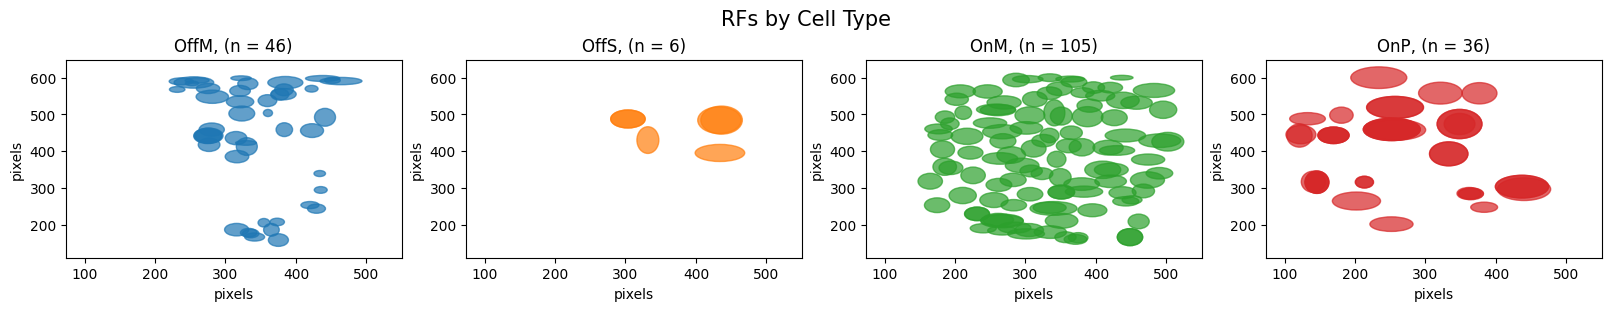

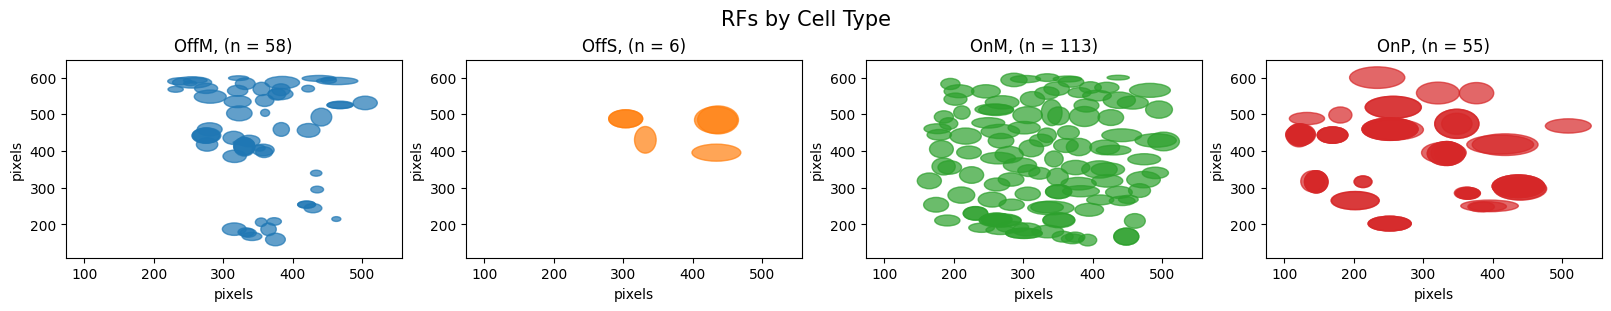

In [5]:
# Canonical types we'd like to look at (these mirror the labels in
# assets/cell_types.csv). The mapper is case-insensitive, so classification
# files using 'All/onP/', 'all/offp/', etc. will still resolve correctly.
requested_types = ['OnP', 'OffP', 'OnM', 'OffM', 'SBC', 'A1', 'BT', 'OnS', 'OffS']

# Re-map the existing cell_type column through the canonical list so any
# odd casing in the classification file collapses to the standard names.
def normalize(t):
    canon = ra.map_cell_type(t)        # case-insensitive lookup against cell_types.csv
    return canon if canon is not None else t

response_block.df_spike_times['cell_type'] = (
    response_block.df_spike_times['cell_type'].apply(normalize)
)

# Show what we ended up with
type_counts = response_block.df_spike_times['cell_type'].value_counts()
print('Cell-type counts (after normalization):')
print(type_counts.head(20))

# Keep only types that (a) are in our requested list and (b) actually exist
# with >=3 cells. Anything missing is silently skipped.
present_types = [t for t, n in type_counts.items() if n >= 3]
cell_types = ra.filter_available_types(requested_types, present_types)
skipped = [t for t in requested_types if t not in cell_types]
print(f'\nUsing cell_types: {cell_types}')
if skipped:
    print(f'Skipping (not present or <3 cells): {skipped}')

if len(cell_types) == 0:
    print('\nNo requested cell types found in this experiment — skipping RF plots.')
else:
    try:
        _ = pipeline.plot_rfs(cell_types=cell_types, minimum_n=3, b_zoom=True)
    except Exception as e:
        print(f'pipeline.plot_rfs skipped: {e}')
    try:
        _ = analysis_chunk.plot_rfs(
            cell_types=cell_types, minimum_n=3, b_zoom=True,
            typing_file=typing_file_name,
        )
    except Exception as e:
        print(f'analysis_chunk.plot_rfs skipped: {e}')

## 5. Inspect stimulus parameters

`stim_block.df_epochs` has one row per epoch with the params that varied (e.g. mean, variance, seed). `d_epoch_block_params` has the block-level params (preTime/stimTime/tailTime, etc.).

In [6]:
display(stim_block.df_epochs.head())

print('\nEpoch-block params:')
for k, v in stim_block.d_epoch_block_params.items():
    print(f'  {k}: {v}')

,epoch_index,backgroundIntensity,currentBackgroundScale,currentImageName,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,0.009608,0.1,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 17.0, 34.0, 50.0, 67.0, 83.0, 100.0, 116...","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32377
1,1,0.960779,10.0,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 115....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32378
2,2,0.035755,0.1,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32379
3,3,3.575503,10.0,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32380
4,4,0.020199,0.1,01151,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32381



Epoch-block params:
  D: 5.0
  amp: Amp1
  preTime: 30000.0
  stimTime: 30000.0
  tailTime: 0.0
  patchMean: all
  randomSeed: 1.0
  sampleRate: 1000.0
  onlineAnalysis: none
  backgroundScale: [0.1, 10.0]
  apertureDiameter: 0.0
  numberOfAverages: 30


## 6. Pull spike times across cells

`get_spike_xarr` returns an xarray with dims `(cell_id, epoch)`, each entry an array of spike times in ms. Coords include `cell_type`, so you can `.sel`/`.where` by type. Filtering by `cell_types` keeps only EI-matched, typed cells.

In [7]:
if len(cell_types) == 0:
    print('No usable cell types — skipping spike xarray.')
    spike_times = None
else:
    spike_times = ra.get_spike_xarr(response_block, cell_types=cell_types, minimum_n=3)
    spike_counts = xr.apply_ufunc(len, spike_times, vectorize=True)

    print(f'Spike xarray shape: {dict(spike_times.sizes)}')
    print(f'Cell types present: {sorted(np.unique(spike_times.cell_type.values))}')

    # Baseline (pre-stim) counts per cell x epoch
    pre_time = stim_block.d_epoch_block_params['preTime']

    def baseline_count(arr, pre_time):
        return int(np.sum(np.asarray(arr) < pre_time))

    baseline_counts = xr.apply_ufunc(
        baseline_count, spike_times,
        kwargs={'pre_time': pre_time}, vectorize=True,
    )

    display(spike_counts)

Spike xarray shape: {'cell_id': 193, 'epoch': 30}
Cell types present: [np.str_('OffM'), np.str_('OffS'), np.str_('OnM'), np.str_('OnP')]


<xarray.DataArray (cell_id: 193, epoch: 30)> Size: 46kB
array([[2555, 1786, 1513, ..., 1485, 1305, 1487],
       [ 272, 1361,  472, ...,  440,  597,  533],
       [2425, 1793, 1303, ...,  429,  990,  582],
       ...,
       [   0,    3,    3, ...,   14,    7,    2],
       [ 227,  213,  117, ...,   68,  143,  126],
       [  33,   47,    0, ...,    0,    0,    0]], shape=(193, 30))
Coordinates:
  * cell_id    (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
    cell_type  (cell_id) <U4 3kB 'OnM' 'OnM' 'OnM' 'OnM' ... 'OffM' 'OnP' 'OnP'
    noise_id   (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
  * epoch      (epoch) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29

## 7. Access STA + EI for a specific cell

After matching, you can look up any protocol cell's noise-chunk twin and grab its STA / EI / timecourse from `analysis_chunk`.

- `pipeline.match_dict[noise_cell_id] = protocol_cell_id` (noise → protocol)
- `analysis_chunk.d_EIs[noise_cell_id]` — electrical image
- `analysis_chunk.d_timecourses[noise_cell_id]` — RGB timecourses
- `analysis_chunk.d_ISIs[noise_cell_id]` — ISI distribution

Noise cell 1  <->  Protocol cell 1
EI shape: (512, 201)
Timecourse channels: ['red', 'green', 'blue']


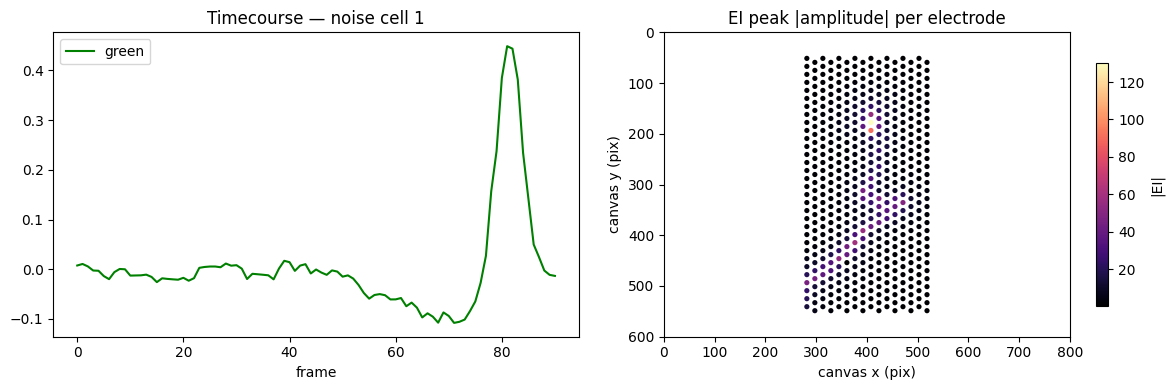

In [8]:
# Example: grab the first matched cell
noise_id, protocol_id = next(iter(pipeline.match_dict.items()))
print(f'Noise cell {noise_id}  <->  Protocol cell {protocol_id}')

ei = analysis_chunk.d_EIs[noise_id]
tc = analysis_chunk.d_timecourses[noise_id]

print(f'EI shape: {ei.shape}')
print(f'Timecourse channels: {list(tc.keys())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: spike-triggered timecourse(s).
axes[0].plot(tc['green'], color='g', label='green')
if not np.allclose(tc['red'], tc['green']):
    axes[0].plot(tc['red'], color='r', label='red')
    axes[0].plot(tc['blue'], color='b', label='blue')
axes[0].set_title(f'Timecourse — noise cell {noise_id}')
axes[0].set_xlabel('frame'); axes[0].legend()

# Right: per-electrode peak |EI| over time, plotted at the electrodes'
# canvas-pixel positions. The MEA-chip → canvas rotation is auto-resolved
# from the rig config (get_display_params_by_exp → mea_rotation_deg),
# so no rig-specific constants are needed in the notebook.
peak_abs = np.abs(ei).max(axis=-1)   # (n_electrodes,)
em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
canvas_w, canvas_h = analysis_chunk.canvas_size
sc = axes[1].scatter(em_canvas[:, 0], em_canvas[:, 1],
                     c=peak_abs, cmap='magma', s=14, edgecolors='none')
axes[1].set_xlim(0, canvas_w); axes[1].set_ylim(canvas_h, 0)
axes[1].set_aspect('equal')
axes[1].set_title(f'EI peak |amplitude| per electrode')
axes[1].set_xlabel('canvas x (pix)'); axes[1].set_ylabel('canvas y (pix)')
fig.colorbar(sc, ax=axes[1], shrink=0.8, label='|EI|')
plt.tight_layout()

## 8. Regenerate the stimulus (optional)

`ra.regen_stimulus(stim_block)` dispatches by protocol name to a per-protocol regen
function (registered in `retinanalysis.regen`). It returns an `xarray.Dataset` with
per-epoch trajectories + metadata, plus base images attached as
`ds.attrs['base_images']` when the protocol's source repo is findable under
`ra.PROTOCOL_REPOS_ROOT`.

If the repo isn't cloned locally, regen still returns trajectories/metadata and
just prints a heads-up — the rest of the notebook keeps working.

PROTOCOL_REPOS_ROOT: /Users/chrischen/Documents/GitHub
Registered regen protocols: ['edu.washington.riekelab.chris.protocols.MEAVariableMeanNoiseCone', 'edu.washington.riekelab.chris.protocols.VariableMeanSpatialNoise', 'edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']

regen_stimulus: using retinanalysis.regen.eye_movement_alt_bg.regen for edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground
[regen] found repo: /Users/chrischen/Documents/GitHub/turner-package
[regen] loaded 5 base image(s) from /Users/chrischen/Documents/GitHub/turner-package/resources/VHsubsample_20160105 (missing: none)

<xarray.Dataset> Size: 880kB
Dimensions:                 (epoch: 30, time: 1800)
Coordinates:
  * epoch                   (epoch) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29
    time_s                  (time) float64 14kB 0.0 0.01667 ... 29.97 29.98
Dimensions without coordinates: time
Data variables:
    xTraj_um                (e

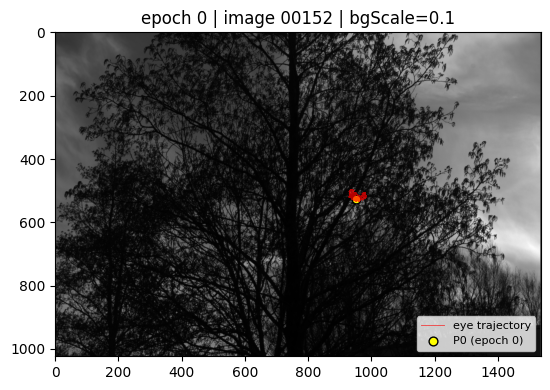

In [9]:
print(f'PROTOCOL_REPOS_ROOT: {ra.PROTOCOL_REPOS_ROOT or "(unset)"}')
print(f'Registered regen protocols: {ra.available_protocols()}\n')

stim_ds = ra.regen_stimulus(stim_block)

if stim_ds is None:
    print('\nNo regen function for this protocol — skipping.')
else:
    print()
    print(stim_ds)
    base_images = stim_ds.attrs.get('base_images', {})
    print(f'\nbase images available: {sorted(base_images.keys()) or "(none)"}')

    if base_images:
        # Show the first epoch's image with the saved P0 marked and the
        # eye-movement trajectory overlaid (in VH pixels, in image coords).
        e = 0
        img_name = str(stim_ds.image_name.values[e])
        img = base_images[img_name]
        p0x = float(stim_ds.currentP0_x_vhpix.values[e])
        p0y = float(stim_ds.currentP0_y_vhpix.values[e])

        um_per_vhpix = stim_ds.attrs['vh_um_per_pixel']
        traj_x_vhpix = stim_ds.xTraj_um.values[e] / um_per_vhpix
        traj_y_vhpix = stim_ds.yTraj_um.values[e] / um_per_vhpix

        fig, ax = plt.subplots(1, 1, figsize=(7, 4))
        ax.imshow(img, cmap='gray', origin='upper')
        ax.plot(p0x + traj_x_vhpix, p0y + traj_y_vhpix,
                color='red', lw=0.6, alpha=0.7, label='eye trajectory')
        ax.scatter([p0x], [p0y], color='yellow', s=40,
                   edgecolor='black', label=f'P0 (epoch {e})')
        ax.set_title(f'epoch {e} | image {img_name} | bgScale={stim_ds.currentBackgroundScale.values[e]:g}')
        ax.legend(loc='lower right', fontsize=8)
        plt.tight_layout()
        plt.show()

## 9. Render the displayed canvas + overlay mosaic and electrodes

`ra.render_displayed_canvas(stim_ds, epoch, frame=...)` returns a
`(canvas_h, canvas_w)` uint8 array — exactly what was on the monitor
that frame. Dispatches on `stim_ds.attrs['protocol_name']`:

- **`EyeMovementTrajectoryAlternatingBackground`**: VH image scaled by
  `vh_um_per_pixel / micronsPerPixel`, centered at canvas + `currentP0`
  offset, shifted by `xTraj_um`/`yTraj_um` at frame `k` (use `frame=None`
  for the pre-trajectory snapshot), background = `imageMean × bgScale`,
  clipped to `canvasSize`.
- **`VariableMeanSpatialNoise`**: stixel grid upscaled by `stixelSizePix`
  via `GL.NEAREST`, centered at canvas + per-frame jitter, background =
  `mean_sequence[frame]`, clipped to `canvasSize`.

The output drops straight into `plot_stim_with_mosaic(..., show_electrodes=True)`
with the default `frame_extent`. Electrodes are taken from
`vcd.get_electrode_map()` (MEA-chip µm) and converted via
`ra.electrode_positions_canvas_px(ac)`. The MEA-chip → canvas rotation
is resolved per rig from `get_display_params_by_exp(exp_name)`
(`mea_rotation_deg` key — Rig C = 90°, verified by minimum-distance
test on matched cells). Override per-call via `electrode_rotation_deg=`.

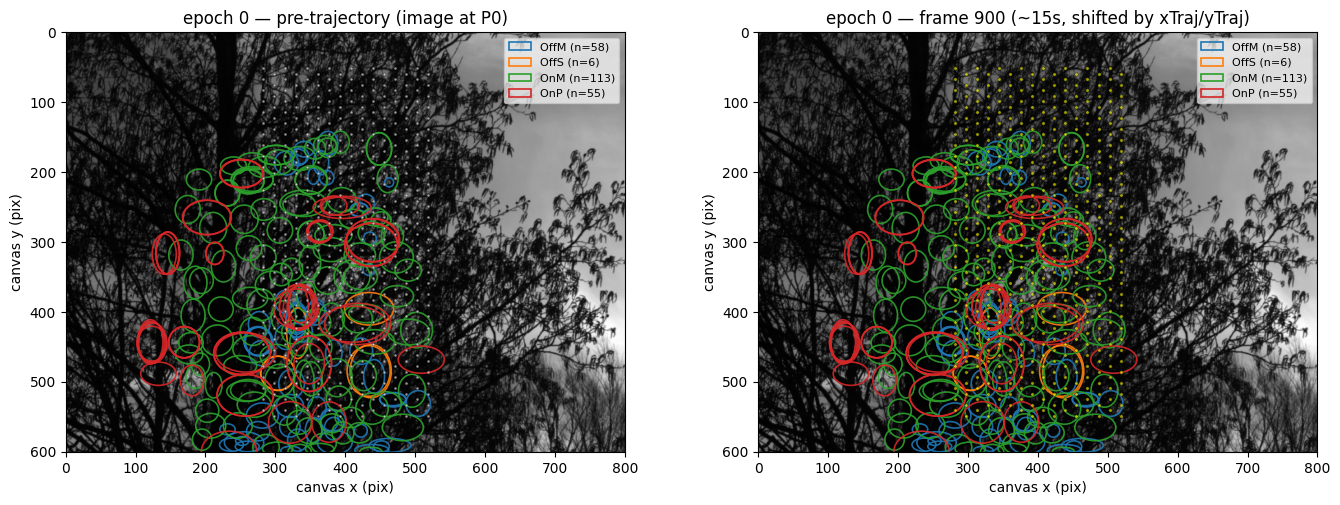

matched cells: n=232, nearest-electrode distance — median=7.8 px (30 µm), 90%ile=88.8 px


In [10]:
if stim_ds is not None and stim_ds.attrs.get('base_images'):
    # render_displayed_canvas → canvas-pixel buffer of exactly what the
    # monitor showed (image scaled by vh_um_per_pixel/microns_per_pixel,
    # offset by currentP0, shifted by eye trajectory at frame `k`,
    # background filled with backgroundIntensity, clipped to canvasSize).
    canvas_t0 = ra.render_displayed_canvas(stim_ds, epoch=0, frame=None)
    canvas_mid = ra.render_displayed_canvas(stim_ds, epoch=0, frame=900)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ra.plot_stim_with_mosaic(
        canvas_t0, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[0], show_electrodes=True,
        title='epoch 0 — pre-trajectory (image at P0)',
    )
    ra.plot_stim_with_mosaic(
        canvas_mid, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[1], show_electrodes=True,
        electrode_kwargs=dict(s=6, c='yellow', edgecolors='black', linewidths=0.4),
        title='epoch 0 — frame 900 (~15s, shifted by xTraj/yTraj)',
    )
    plt.tight_layout()
    plt.show()

    # Sanity check: matched cells should sit close to electrodes (each cell
    # is recorded by a nearby electrode). On a 30 µm hex array the typical
    # nearest-electrode distance is ~half the pitch (~15 µm).
    em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
    ppstix = analysis_chunk.pixels_per_stixel
    matched = (analysis_chunk.df_cell_params
               .query('typing_file_0 in @cell_types')['cell_id'].values)
    dists = []
    for cid in matched:
        rf = analysis_chunk.rf_params[cid]
        sta_xy = np.array([rf['center_x'] * ppstix, rf['center_y'] * ppstix])
        dists.append(np.linalg.norm(em_canvas - sta_xy, axis=1).min())
    dists = np.asarray(dists)
    print(f'matched cells: n={len(dists)}, '
          f'nearest-electrode distance — median={np.median(dists):.1f} px '
          f'({np.median(dists) * analysis_chunk.microns_per_pixel:.0f} µm), '
          f'90%ile={np.percentile(dists, 90):.1f} px')
else:
    print('No regen base images available — skipping displayed-canvas demo.')

## 10. Same pipeline for `VariableMeanSpatialNoise`

This experiment didn't run `VariableMeanSpatialNoise`, but we can
synthesize a stim_block matching the rig (`canvasSize=[800, 600]`,
`micronsPerPixel=3.8`) and feed it through the same dispatcher to
see what the noise stimulus would look like overlaid on the
mosaic + electrodes. Switching protocols requires no extra plumbing —
`regen_stimulus` and `render_displayed_canvas` route on
`stim_block.protocol_name` / `stim_ds.attrs['protocol_name']`.

regen_stimulus: using retinanalysis.regen.variable_mean_spatial_noise.regen for edu.washington.riekelab.chris.protocols.VariableMeanSpatialNoise


[regen] VariableMeanSpatialNoise: 1 epochs × 120 frames × 26×35 stixels (contrast=1.0, rng=matlab)
[matlab_engine] starting MATLAB engine (~5-10s)...


[matlab_engine] MATLAB engine ready.


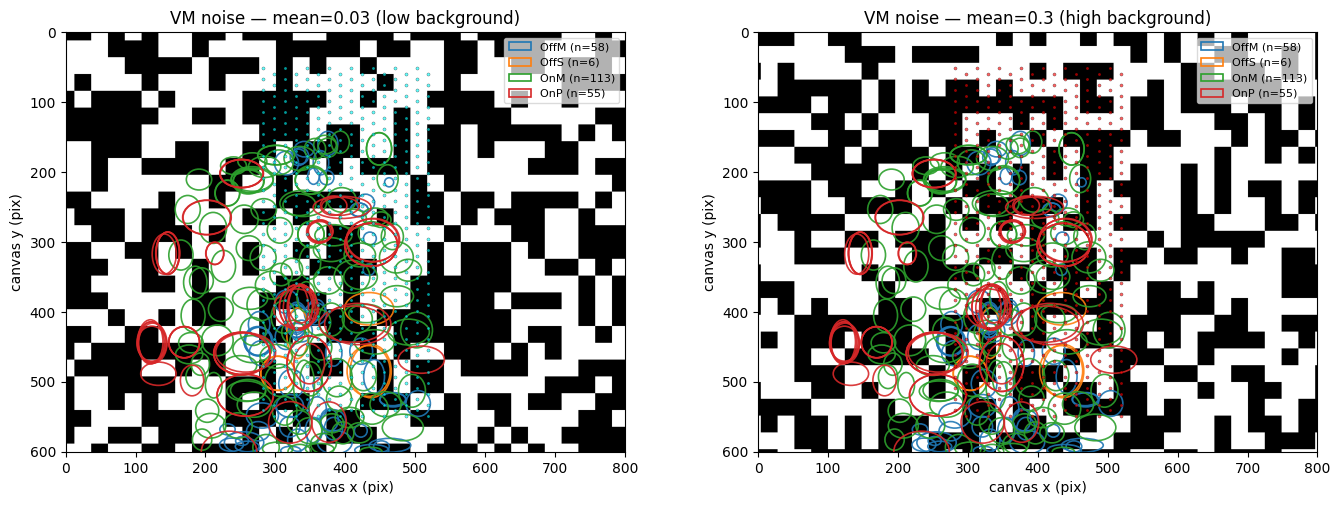

In [11]:
import pandas as pd
from types import SimpleNamespace

# Use the real rig's display params so the rendered noise lives in the same
# canvas-pixel coords as the mosaic + electrodes.
canvas_size = list(analysis_chunk.canvas_size)         # [800, 600]
mu_per_pix  = float(analysis_chunk.microns_per_pixel)  # 3.8
grid_um     = 30                                       # protocol default
stixel_um   = 90                                       # protocol default → stepsPerStixel=3
steps_per_stixel = max(round(stixel_um / grid_um), 1)
grid_size_pix   = round(grid_um / mu_per_pix)          # 8
stixel_size_pix = grid_size_pix * steps_per_stixel     # 24
n_x = int(np.ceil(canvas_size[0] / stixel_size_pix) + 1)
n_y = int(np.ceil(canvas_size[1] / stixel_size_pix) + 1)

mean_intensities = [0.03, 0.3]                          # low / high mean
total_frames = 120                                      # 2 s @ 60 Hz
frames_per_switch = 60                                  # 1 s per mean (block-level=1000 ms)

epoch_params = [{
    'seed': 42,
    'numXStixels': n_x, 'numYStixels': n_y,
    'numXChecks': n_x * steps_per_stixel, 'numYChecks': n_y * steps_per_stixel,
    'stixelSize': stixel_um, 'stepsPerStixel': steps_per_stixel,
    'frameDwell': 1, 'meanSwitchInterval': 1000,
    'meanIntensities': mean_intensities,
    'totalFrames': total_frames, 'framesPerSwitch': frames_per_switch,
    'canvasSize': canvas_size, 'micronsPerPixel': mu_per_pix, 'gridSize': grid_um,
}]
synth_stim = SimpleNamespace(
    protocol_name='edu.washington.riekelab.chris.protocols.VariableMeanSpatialNoise',
    exp_name=analysis_chunk.exp_name, datafile_name='(synthetic)',
    df_epochs=pd.DataFrame({'epoch_parameters': epoch_params}),
    d_epoch_block_params={
        'preTime': 250, 'stimTime': 2000, 'tailTime': 250,
        'contrast': 1.0, 'gridSize': grid_um, 'meanSwitchInterval': 1000,
        'meanIntensities': mean_intensities,
    },
)

# Regen → render → overlay. Same three calls as for the eye-movement protocol.
ds_vm = ra.regen_stimulus(synth_stim, verbose=True)
canvas_low  = ra.render_displayed_canvas(ds_vm, epoch=0, frame=0)    # mean=0.03
canvas_high = ra.render_displayed_canvas(ds_vm, epoch=0, frame=60)   # mean=0.30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ra.plot_stim_with_mosaic(
    canvas_low, analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[0], show_electrodes=True,
    electrode_kwargs=dict(s=5, c='cyan', edgecolors='black', linewidths=0.3),
    title=f'VM noise — mean={mean_intensities[0]} (low background)',
)
ra.plot_stim_with_mosaic(
    canvas_high, analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[1], show_electrodes=True,
    electrode_kwargs=dict(s=5, c='red', edgecolors='black', linewidths=0.3),
    title=f'VM noise — mean={mean_intensities[1]} (high background)',
)
plt.tight_layout()
plt.show()